In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from collections import Counter
import random
import numpy as np
from pathlib import Path

In [6]:
# -----------------------------
# 1. Sample corpus
# -----------------------------
!python prep_fairytales.py --indir ./raw_fairytales --outdir corpus --lower --dedup

Loaded raw_fairytales\7439-h.htm
{
  "stories": 1,
  "tokens": 61026,
  "vocab": 5658,
  "removed_non_english": 0,
  "generated_at": "2026-02-18T16:03:46.572569Z"
}
✔ Wrote 1 stories to corpus\clean


c:\Users\Tânia\Work\word2vec\prep_fairytales.py:213: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "generated_at": datetime.utcnow().isoformat() + "Z",


In [8]:
def iter_tokens(tokens_path: Path):
    with tokens_path.open("r", encoding="utf-8") as f:
        for line in f:
            yield line.strip().split()

tokens_path = Path('.\\corpus\\clean\\corpus.txt')
tokenized_corpus = list(iter_tokens(tokens_path))

In [9]:
# 1. Preprocessing with Min-Count Filtering
def prepare_data(tokenized_corpus, min_count=5):
    # Count frequencies
    word_counts = Counter([word for sentence in tokenized_corpus for word in sentence])
    # Filter vocab
    vocab = {word: count for word, count in word_counts.items() if count >= min_count}
    word2idx = {word: idx for idx, word in enumerate(vocab.keys())}
    idx2word = {idx: word for word, idx in word2idx.items()}
    
    # Filter sentences to only include words in the new vocab
    filtered_corpus = [[w for w in s if w in word2idx] for s in tokenized_corpus]
    return filtered_corpus, word2idx, idx2word, len(word2idx)

In [10]:
# 2. Skip-gram Data Generation
def generate_skipgram_data(tokenized_corpus, word2idx, window_size=3):
    pairs = []
    for sentence in tokenized_corpus:
        indices = [word2idx[w] for w in sentence]
        for center_idx, center_word in enumerate(indices):
            context_range = range(max(0, center_idx - window_size), 
                                  min(len(indices), center_idx + window_size + 1))
            for context_idx in context_range:
                if context_idx != center_idx:
                    pairs.append((center_word, indices[context_idx]))
    return pairs

In [11]:
# 3. Optimized Model using Dot Product
class Word2VecSGNS(nn.Module):
    def __init__(self, vocab_size, embedding_dim):
        super(Word2VecSGNS, self).__init__()
        self.in_embed = nn.Embedding(vocab_size, embedding_dim)
        self.out_embed = nn.Embedding(vocab_size, embedding_dim)
        # Initialize weights to small values
        initrange = 0.5 / embedding_dim
        self.in_embed.weight.data.uniform_(-initrange, initrange)
        self.out_embed.weight.data.uniform_(-0, 0)

    def forward(self, center_words, pos_words, neg_words):
        # center: (batch), pos: (batch), neg: (batch, num_neg)
        
        v = self.in_embed(center_words).unsqueeze(2)    # (batch, dim, 1)
        u_pos = self.out_embed(pos_words).unsqueeze(1) # (batch, 1, dim)
        u_neg = self.out_embed(neg_words)              # (batch, num_neg, dim)

        # Log-sigmoid loss for positive pairs (Dot product)
        pos_score = torch.bmm(u_pos, v).squeeze()      # (batch)
        pos_loss = F.logsigmoid(pos_score)

        # Log-sigmoid loss for negative pairs
        neg_score = torch.bmm(u_neg, v).squeeze()      # (batch, num_neg)
        neg_loss = F.logsigmoid(-neg_score).sum(1)     # Sum over negative samples

        return -(pos_loss + neg_loss).mean()

In [21]:
# 4. Training Setup
# Assuming tokenized_corpus is already loaded from your previous cell
filtered_corpus, word2idx, idx2word, vocab_size = prepare_data(tokenized_corpus, min_count=5)
training_pairs = generate_skipgram_data(filtered_corpus, word2idx)

embedding_dim = 50 
model = Word2VecSGNS(vocab_size, embedding_dim)
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 100
batch_size = 512
num_negatives = 10

In [22]:
# 5. Training Loop
epoch_loss = []
for epoch in range(epochs):
    total_loss = 0
    random.shuffle(training_pairs)
    
    for i in range(0, len(training_pairs), batch_size):
        batch = training_pairs[i:i+batch_size]
        if len(batch) < batch_size: continue
            
        centers = torch.LongTensor([c for c, p in batch])
        positives = torch.LongTensor([p for c, p in batch])
        
        # Simple negative sampling
        negatives = torch.randint(0, vocab_size, (batch_size, num_negatives))

        optimizer.zero_grad()
        loss = model(centers, positives, negatives)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    epoch_loss.append(total_loss)
    print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss:.4f}")
torch.save(model, "word2vect_tania_sgns.pt")

Epoch 1/100, Loss: 2061.2319
Epoch 2/100, Loss: 1292.6078
Epoch 3/100, Loss: 1280.4486
Epoch 4/100, Loss: 1278.8270
Epoch 5/100, Loss: 1278.5275
Epoch 6/100, Loss: 1272.9144
Epoch 7/100, Loss: 1258.9445
Epoch 8/100, Loss: 1241.8912
Epoch 9/100, Loss: 1225.8903
Epoch 10/100, Loss: 1211.8856
Epoch 11/100, Loss: 1198.6468
Epoch 12/100, Loss: 1187.0955
Epoch 13/100, Loss: 1175.0911
Epoch 14/100, Loss: 1165.6913
Epoch 15/100, Loss: 1156.2154
Epoch 16/100, Loss: 1147.2271
Epoch 17/100, Loss: 1139.8021
Epoch 18/100, Loss: 1132.4117
Epoch 19/100, Loss: 1125.2258
Epoch 20/100, Loss: 1118.0670
Epoch 21/100, Loss: 1111.8693
Epoch 22/100, Loss: 1105.1744
Epoch 23/100, Loss: 1100.3270
Epoch 24/100, Loss: 1095.0841
Epoch 25/100, Loss: 1088.3039
Epoch 26/100, Loss: 1085.1109
Epoch 27/100, Loss: 1079.6150
Epoch 28/100, Loss: 1076.0965
Epoch 29/100, Loss: 1069.6457
Epoch 30/100, Loss: 1065.7111
Epoch 31/100, Loss: 1062.3621
Epoch 32/100, Loss: 1059.7712
Epoch 33/100, Loss: 1054.6080
Epoch 34/100, Loss:

Text(0.5, 1.0, 'Training Loss Curve')

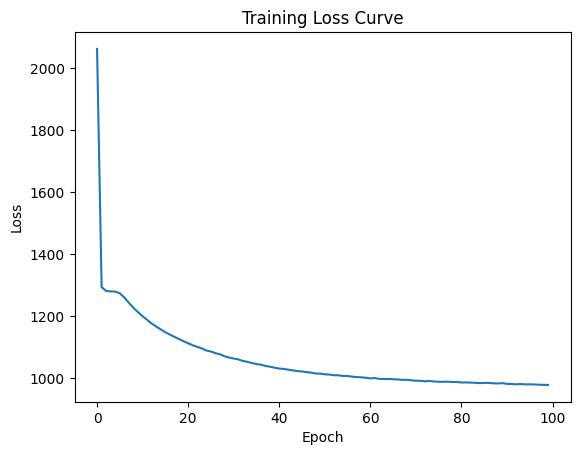

In [23]:
#plotting the loss curve
import matplotlib.pyplot as plt
plt.plot(epoch_loss)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Curve')

In [28]:

# 6. Evaluation Function (Cosine Similarity for Inference only)
def find_similar(word, top_n=5):
    if word not in word2idx: return "Not in vocab"
    
    # Use 'in' embeddings for similarity
    weights = model.in_embed.weight.data
    query_vec = weights[word2idx[word]]
    
    # Cosine similarity: (A dot B) / (||A|| * ||B||)
    cos_sim = F.cosine_similarity(query_vec.unsqueeze(0), weights)
    
    scores, indices = torch.topk(cos_sim, top_n + 1)
    for i in range(1, len(indices)): # skip the word itself
        print(f"{idx2word[indices[i].item()]}: {scores[i].item():.4f}")

print("\nResults for 'king':")
find_similar("king")


Results for 'king':
stole: 0.6386
creature: 0.5695
queen: 0.5530
ducky-daddles.: 0.5360
leave: 0.5233


In [25]:
def find_similar_embedding(positive, negative, top_n=5):
    positive_negative = positive + negative
    cos = nn.CosineSimilarity(dim=0, eps=1e-6)

    weights = model.in_embed.weight.data

    for item in positive_negative:
        if item not in word2idx:
            print(f"{item} not in vocabulary")

    query_vec = weights[word2idx[positive[0]]] - weights[word2idx[negative[0]]] + weights[word2idx[positive[1]]]
    
    # Compute cosine similarity with all other words
    similarities = {}
    for word, idx in word2idx.items():
        if word not in positive_negative:
            
            sim = cos(query_vec,weights[idx])
            similarities[word] = sim
    
    # Sort by similarity
    similar_words = sorted(similarities.items(), key=lambda x: x[1], reverse=True)[:top_n]
    
    print(f"\nTop {top_n} words similar to embedding:")
    for word, score in similar_words:
        print(f"{word}: {score:.4f}")

In [30]:
find_similar_embedding(positive = ['mother','woman'], negative = ['man'], top_n=5)


Top 5 words similar to embedding:
body: 0.5396
jack's: 0.4908
house: 0.4837
bone: 0.4770
frightened,: 0.4739
